# 01 — Dataset, preprocesamiento resumido y splits congelados

**TP Final · Aprendizaje de Máquina I (CEIA-FIUBA)** · Jaime Pinzón (a2629)

## 1. Propuesta de investigación

**Pregunta:** ¿cuántos días permanecerá internado un paciente diabético, estimado al momento de su ingreso, a partir de la información clínica y administrativa disponible en la admisión?

**Motivación de negocio.** La duración de la estadía (*length of stay*) es uno de los principales determinantes del costo hospitalario y de la disponibilidad de camas. Un modelo con error medio bajo permite planificar ocupación de camas, dimensionar personal por adelantado y detectar tempranamente pacientes con riesgo de estadía prolongada. Por eso la métrica principal de todo el trabajo es el **MAE en días** — directamente interpretable por la gestión — acompañada de RMSE y R².

**Problema de ML:** regresión supervisada sobre el target `time_in_hospital` (1–14 días). En los notebooks siguientes se comparan cinco familias de modelos (KNN, SVR, árbol de regresión, Random Forest, XGBoost) contra baselines simples, con hiperparámetros optimizados por validación cruzada.

### Qué se pretende descubrir

La predicción es el instrumento, no el objetivo. Las tres preguntas que este trabajo se propone responder — y que se retoman una por una en las conclusiones del notebook 07 — son:

1. **¿Alcanza la información disponible en la admisión para anticipar la estadía?** Es decir, ¿dónde está el techo de predictibilidad y es una limitación de los modelos o de los datos? La hipótesis previa es que **el límite está en los datos**: la duración de una internación depende sobre todo de eventos posteriores al ingreso, así que se espera un R² modesto por más que se sofistique el algoritmo.
2. **¿Qué variables de admisión gobiernan la duración?** ¿La señal está en el diagnóstico (lo que el paciente *tiene*) o en la intensidad de tratamiento inicial (lo que el hospital *hace*)? La respuesta cambia cuándo puede correrse el modelo dentro del circuito de admisión.
3. **¿Cuánto importa la elección de la familia de algoritmos frente a la disciplina metodológica?** Se espera que, una vez capturada la no linealidad principal, la distancia entre familias sea mucho menor que la distancia contra un baseline honesto.

Cada una tiene una respuesta cuantificada en el notebook 07; la tercera es, además, la tesis metodológica de la materia puesta a prueba sobre datos propios.

## 2. Fuente de datos

> Strack, B., DeShazo, J., Gennings, C., Olmo, J. L., Ventura, S., Cios, K. J., & Clore, J. N. (2014). *Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records*. BioMed Research International. DOI: [10.1155/2014/781670](https://doi.org/10.1155/2014/781670)
>
> Dataset: **Diabetes 130-US Hospitals for Years 1999–2008** — UCI Machine Learning Repository. DOI: [10.24432/C5230J](https://doi.org/10.24432/C5230J) · Licencia: CC BY 4.0

Cada observación es un encuentro hospitalario de un paciente diagnosticado con diabetes, en 130 hospitales de EE.UU. durante 1999–2008: 101.766 registros y 50 variables (datos demográficos, diagnósticos ICD-9, medicaciones, utilización previa del sistema de salud).

El análisis exploratorio completo y las decisiones de preprocesamiento provienen del trabajo final de **Análisis de Datos** (Grupo 3, mismo autor): [CEIA_Analisis_de_datos/trabajo_final](https://github.com/masouto94/CEIA_Analisis_de_datos). Siguiendo el criterio de la cátedra, aquí solo se **resume** ese trabajo y el foco está en el entrenamiento y la evaluación.

In [1]:
import numpy as np
import pandas as pd

from src.config import (
    COLS_FILTRO_IQR, DIR_PROCESSED, FEATURES_FINALES, SEED, TARGET,
)
from src.preprocesamiento import (
    cargar_y_limpiar, descargar_si_falta, filtrar_outliers_train,
    procesar, split_estratificado,
)
from src.pipelines import build_preprocessor

pd.set_option("display.max_columns", 60)
SEED

42

## 3. Preprocesamiento resumido (portado de Análisis de Datos)

Tabla-síntesis de las decisiones tomadas en AdD y qué se porta acá. La regla del porte: los parquets finales contienen **solo transformaciones sin estado**; cualquier transformación que aprende de los datos (OneHot, TargetEncoder, escalado) vive dentro del `Pipeline` de cada modelo (`src/pipelines.py`) y se re-fitea por fold en validación cruzada.

| Decisión en AdD | Justificación original | ¿Se porta? |
|---|---|---|
| `weight` eliminada | 97% faltante (tema legislativo en EE.UU.) | No hace falta: no sobrevive la selección |
| `max_glu_serum`, `A1Cresult` → "desconocido" | Ausentes estructurales (test no realizado) | Ídem |
| `race` → "Other", `payer_code`/`medical_specialty` → "Unknown" | MCAR / faltantes masivos | Ídem |
| Cascada de diagnósticos `diag_1 > diag_2 > diag_3` | Faltantes ≤1%, imputación por jerarquía clínica | **Sí** |
| Mapeo ICD-9 → 21 categorías clínicas | Reducción de cardinalidad (~700 códigos → 21) | **Sí** (determinista, sin estado) |
| `examide`, `citoglipton` descartadas | Varianza cero | No hace falta: no sobreviven la selección |
| Split 80/20, seed 42, estratificado por target | Target discreto (1–14), preserva distribución | **Sí** (idéntico) |
| Filtro IQR de outliers **solo en train** | Reduce asimetría; test intocado | **Sí** (idéntico) |
| `in_out_emergency` (feature nueva) | Condensa visitas previas | **No**: la selección final de AdD no la retuvo (código muerto) |
| Selección por información mutua + correlaciones | 8 variables base retenidas | **Sí** (lista fija `FEATURES_FINALES`) |
| OneHot(`age`), TargetEncoder(`diag_*`) | Codificación por cardinalidad | **Sí, pero dentro del Pipeline** (nunca en los parquets) |
| PCA (11 de 17 componentes) | Reducción de dimensionalidad | **No** en el pipeline principal (decisión D1 del plan); posible anexo |

**Nota de fidelidad:** en el original, la línea que reemplazaba `?` en `diag_1` no asignaba el resultado (no-op). Es inocuo: el mapeo ICD-9 envía tanto `?` como `None` a la categoría 0. El porte replica el comportamiento efectivo.

Las 8 variables finales: `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses` (numéricas), `age` (categórica ordinal en rangos de 10 años) y `diag_1/2/3` (categorías ICD-9).

In [2]:
# Descarga (si hace falta) y carga del crudo
descargar_si_falta()
from src.config import CSV_CRUDO
crudo = pd.read_csv(CSV_CRUDO)
print(f"Dataset crudo: {crudo.shape[0]:,} filas x {crudo.shape[1]} columnas")
crudo[FEATURES_FINALES + [TARGET]].head(3)

Dataset crudo: 101,766 filas x 50 columnas


,num_lab_procedures,num_procedures,num_medications,number_diagnoses,age,diag_1,diag_2,diag_3,time_in_hospital
0,41,0,1,1,[0-10),250.83,?,?,1
1,59,0,18,9,[10-20),276,250.01,255,3
2,11,5,13,6,[20-30),648,250,V27,2


In [3]:
# Limpieza sin estado: cascada de diagnosticos + mapeo ICD-9 + dtypes
X, y = cargar_y_limpiar()
print(f"X: {X.shape} (8 features finales + 3 columnas auxiliares del filtro IQR)")
print(f"y: {y.shape}, rango {y.min():.0f}-{y.max():.0f} dias")
X.head(3)

X: (101766, 11) (8 features finales + 3 columnas auxiliares del filtro IQR)
y: (101766,), rango 1-14 dias


,num_lab_procedures,num_procedures,num_medications,number_diagnoses,age,diag_1,diag_2,diag_3,number_outpatient,number_emergency,number_inpatient
0,41,0,1,1,[0-10),20,20,20,0,0,0
1,59,0,18,9,[10-20),3,20,3,0,0,0
2,11,5,13,6,[20-30),11,20,18,2,0,1


## 4. Split estratificado 80/20

Idéntico al de AdD: `random_state=42`, estratificado por el target. Como `time_in_hospital` es discreto (1–14 días), estratificar garantiza que train y test tengan la misma distribución de estadías — importante porque la distribución es asimétrica (mayoría de estadías cortas).

In [4]:
X_train_full, X_test_full, y_train_full, y_test = split_estratificado(X, y)

comparacion = pd.DataFrame({
    "original": y.value_counts(normalize=True).sort_index(),
    "train": y_train_full.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
}).round(4)
print(f"train: {X_train_full.shape[0]:,} filas | test: {X_test_full.shape[0]:,} filas")
comparacion.T

train: 81,412 filas | test: 20,354 filas


time_in_hospital,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
original,0.1396,0.1693,0.1745,0.1368,0.0979,0.0741,0.0576,0.0431,0.0295,0.023,0.0182,0.0142,0.0119,0.0102
train,0.1396,0.1693,0.1745,0.1368,0.0979,0.0741,0.0576,0.0432,0.0295,0.023,0.0182,0.0142,0.0119,0.0102
test,0.1396,0.1693,0.1745,0.1368,0.0979,0.0741,0.0576,0.0431,0.0295,0.023,0.0182,0.0142,0.0119,0.0102


## 5. Filtro de outliers IQR — solo sobre train

Los umbrales $[Q_1 - 1.5\,\mathrm{IQR},\; Q_3 + 1.5\,\mathrm{IQR}]$ se calculan **sobre el train** para las 7 columnas numéricas y el target, y se conservan las filas donde todas las columnas están dentro de sus límites (réplica exacta de AdD, que marcaba outliers con NaN y hacía un único `dropna`).

**El test no se filtra jamás**: en producción no se puede descartar un paciente por tener valores extremos, así que la evaluación debe incluirlos. Esto implica que el test conserva estadías de hasta 14 días aunque el train quede acotado — los modelos serán evaluados también sobre casos que no vieron en entrenamiento, y eso es deliberado y honesto.

### Auditoría del filtro heredado: qué descarta realmente

El filtro se porta de AdD *por fidelidad*, pero antes de aceptarlo conviene auditar columna por columna qué hace — y el resultado no es el que sugiere el nombre "filtro de outliers". La celda siguiente lo muestra: en `number_outpatient` y `number_emergency` la distribución es tan asimétrica que **Q1 = Q3 = 0**, con lo cual IQR = 0 y los límites **colapsan al intervalo degenerado [0, 0]**. Para esas dos columnas el criterio deja de ser "descartar valores extremos" y pasa a ser *"conservar únicamente pacientes sin ninguna visita ambulatoria ni de emergencia previa"* — una **selección de subpoblación**, no una limpieza.

Es, con diferencia, la decisión de preprocesamiento más costosa del trabajo, y no era visible en la tabla-síntesis de la sección 3. Se la documenta acá con números, se cuantifica el desplazamiento que induce entre train y test, y en el **notebook 07 se la somete a una ablación completa** (reentrenar el modelo ganador sin el filtro) para medir cuánto de lo que después se llamará "techo de predictibilidad" es de los datos y cuánto es autoinfligido.

Se mantiene el filtro en el pipeline principal para preservar la fidelidad al trabajo de AdD y la comparabilidad de las diez filas de `metricas.csv` entre sí; la ablación reporta el costo de esa decisión en lugar de esconderlo.

In [5]:
X_train, y_train = filtrar_outliers_train(X_train_full, y_train_full)
X_test = X_test_full[FEATURES_FINALES].reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"train filtrado: {X_train.shape} | y_train: {y_train.shape}")
print(f"test SIN filtrar: {X_test.shape} | y_test: {y_test.shape}")
print(f"y_train: {y_train.min():.0f}-{y_train.max():.0f} dias | y_test: {y_test.min():.0f}-{y_test.max():.0f} dias")

# Verificacion contra los shapes del trabajo original de AdD
assert X_train.shape == (53756, 8), X_train.shape
assert y_train.shape == (53756,), y_train.shape
assert X_test.shape == (20354, 8), X_test.shape
assert y_test.shape == (20354,), y_test.shape
print("Shapes identicos a los del trabajo de AdD (53.756 train / 20.354 test)")

train filtrado: (53756, 8) | y_train: (53756,)
test SIN filtrar: (20354, 8) | y_test: (20354,)
y_train: 1-12 dias | y_test: 1-14 dias
Shapes identicos a los del trabajo de AdD (53.756 train / 20.354 test)


In [6]:
# --- Auditoria del filtro heredado: cuanto descarta cada columna y por que ---
filas = []
for col in COLS_FILTRO_IQR:
    serie = X_train_full[col]
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    inf, sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    descarta = int((~serie.between(inf, sup)).sum())
    filas.append({
        "columna": col, "Q1": q1, "Q3": q3, "IQR": iqr,
        "limite_inf": inf, "limite_sup": sup,
        "descarta": descarta,
        "%_train": round(100 * descarta / len(X_train_full), 1),
        "degenerado": "SI (IQR=0)" if iqr == 0 else "",
        "es_feature": "si" if col in FEATURES_FINALES else "NO",
    })

q1, q3 = y_train_full.quantile(0.25), y_train_full.quantile(0.75)
iqr = q3 - q1
fuera_target = int((~y_train_full.between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)).sum())
filas.append({
    "columna": TARGET, "Q1": q1, "Q3": q3, "IQR": iqr,
    "limite_inf": q1 - 1.5 * iqr, "limite_sup": q3 + 1.5 * iqr,
    "descarta": fuera_target,
    "%_train": round(100 * fuera_target / len(y_train_full), 1),
    "degenerado": "", "es_feature": "no (es el target)",
})

auditoria = pd.DataFrame(filas)
descartado_pct = 100 * (1 - len(X_train) / len(X_train_full))
print(f"Train antes del filtro: {len(X_train_full):,} filas")
print(f"Train despues del filtro: {len(X_train):,} filas ({descartado_pct:.1f}% descartado)")
print()
print(auditoria.to_string(index=False))


Train antes del filtro: 81,412 filas
Train despues del filtro: 53,756 filas (34.0% descartado)



           columna   Q1   Q3  IQR  limite_inf  limite_sup  descarta  %_train degenerado        es_feature
num_lab_procedures 32.0 57.0 25.0        -5.5        94.5       179      0.2                           si
    num_procedures  0.0  2.0  2.0        -3.0         5.0      4003      4.9                           si
   num_medications 10.0 20.0 10.0        -5.0        35.0      2026      2.5                           si
 number_outpatient  0.0  0.0  0.0         0.0         0.0     13363     16.4 SI (IQR=0)                NO
  number_emergency  0.0  0.0  0.0         0.0         0.0      9096     11.2 SI (IQR=0)                NO
  number_inpatient  0.0  1.0  1.0        -1.5         2.5      5605      6.9                           NO
  number_diagnoses  6.0  9.0  3.0         1.5        13.5       231      0.3                           si
  time_in_hospital  2.0  6.0  4.0        -4.0        12.0      1802      2.2            no (es el target)


**Lectura de la auditoría.** Dos columnas dominan el descarte y ninguna de las dos es una feature del modelo:

- `number_outpatient` (**16,4%** del train) y `number_emergency` (**11,2%**) tienen `Q1 = Q3 = 0`, así que sus límites colapsan a `[0, 0]`: el "filtro de outliers" está exigiendo **cero visitas ambulatorias y cero visitas de emergencia previas**. Junto con `number_inpatient` (6,9%, límite superior 2,5 internaciones previas), las tres columnas de utilización previa del sistema de salud —que solo participan del filtrado y después se descartan— explican casi todo el recorte.
- Las cuatro columnas que sí son features aportan poco (0,2% a 4,9%) y el target apenas 2,2%.

El efecto neto es que el train pierde el **34%** de sus filas, y lo pierde de forma **sistemática, no aleatoria**: se queda con los pacientes de menor utilización histórica del sistema. La celda siguiente mide qué proporción del test cae fuera de esa subpoblación — es decir, sobre cuántos pacientes el modelo va a predecir sin haber visto a nadie parecido.

In [7]:
# --- Cuanto del TEST queda fuera de la subpoblacion que el train conserva? ---
limites = {}
for col in COLS_FILTRO_IQR:
    q1, q3 = X_train_full[col].quantile(0.25), X_train_full[col].quantile(0.75)
    iqr = q3 - q1
    limites[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

dentro = pd.Series(True, index=X_test_full.index)
for col, (inf, sup) in limites.items():
    dentro &= X_test_full[col].between(inf, sup)

mask = dentro.values          # y_test ya tiene indice reseteado: se indexa posicionalmente
n_fuera = int((~mask).sum())
print(f"Test: {len(X_test_full):,} pacientes")
print(f"  dentro de la subpoblacion del train: {int(mask.sum()):,} ({100 * mask.mean():.1f}%)")
print(f"  FUERA (sin analogos en el train)   : {n_fuera:,} ({100 * (~mask).mean():.1f}%)")
print()

comp = pd.DataFrame({
    "estadia media (dias)": [y_test[mask].mean(), y_test[~mask].mean()],
    "estadia mediana": [y_test[mask].median(), y_test[~mask].median()],
    "n": [int(mask.sum()), n_fuera],
}, index=["dentro de la subpoblacion", "fuera de la subpoblacion"])
print(comp.round(2).to_string())
print()
print("Los pacientes excluidos del train tienen estadias sistematicamente MAS LARGAS:")
print(f"  {y_test[~mask].mean() - y_test[mask].mean():+.2f} dias de diferencia.")
print("  Son justamente los casos que mas le importan a la gestion de camas.")


Test: 20,354 pacientes
  dentro de la subpoblacion del train: 13,742 (67.5%)
  FUERA (sin analogos en el train)   : 6,612 (32.5%)

                           estadia media (dias)  estadia mediana      n
dentro de la subpoblacion                  4.26              4.0  13742
fuera de la subpoblacion                   4.67              4.0   6612

Los pacientes excluidos del train tienen estadias sistematicamente MAS LARGAS:
  +0.41 dias de diferencia.
  Son justamente los casos que mas le importan a la gestion de camas.


### Por qué esta figura importa

La distribución del target justifica tres decisiones que se toman más adelante y que de otro modo habría que aceptar por confianza:

- **Por qué MAE y no RMSE como métrica primaria**: la distribución es discreta y asimétrica a derecha (skew ≈ 1), con una cola de estadías largas. El RMSE quedaría dominado por esa cola; el MAE es el error que la gestión de camas puede leer directamente en días.
- **El desplazamiento train/test es visible, no teórico**: el panel derecho muestra el corte en 12 días del train frente a las estadías de 13–14 que el test conserva. Es la causa del fenómeno media-vs-mediana que aparece en el notebook 02 y de parte del techo de R² que se discute en el 07.
- **La asimetría anticipa la elección de `reg:absoluteerror`** en XGBoost (decisión D4, notebook 06): con una cola así, optimizar L2 arrastra las predicciones hacia arriba.

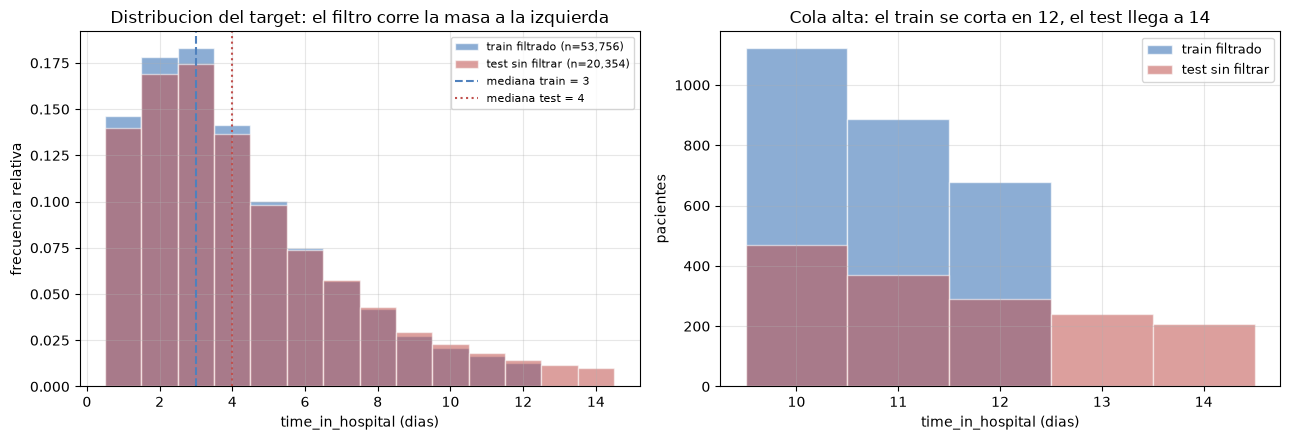

train: media=4.087  mediana=3  skew=0.985  rango=1-12
test : media=4.396  mediana=4  skew=1.134  rango=1-14

Estadias de 13-14 dias en el test: 450 pacientes,
de los que el train no contiene NI UNO.


In [8]:
# --- Distribucion del target: train filtrado vs test sin filtrar ---
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.arange(0.5, 15.5, 1)

axes[0].hist(y_train, bins=bins, density=True, alpha=0.65, color="#4f81bd",
             edgecolor="white", label=f"train filtrado (n={len(y_train):,})")
axes[0].hist(y_test, bins=bins, density=True, alpha=0.55, color="#c0504d",
             edgecolor="white", label=f"test sin filtrar (n={len(y_test):,})")
axes[0].axvline(y_train.median(), color="#4f81bd", linestyle="--",
                label=f"mediana train = {y_train.median():.0f}")
axes[0].axvline(y_test.median(), color="#c0504d", linestyle=":",
                label=f"mediana test = {y_test.median():.0f}")
axes[0].set_xlabel("time_in_hospital (dias)")
axes[0].set_ylabel("frecuencia relativa")
axes[0].set_title("Distribucion del target: el filtro corre la masa a la izquierda")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

cola = np.arange(9.5, 15.5, 1)
axes[1].hist(y_train, bins=cola, alpha=0.65, color="#4f81bd", edgecolor="white",
             label="train filtrado")
axes[1].hist(y_test, bins=cola, alpha=0.55, color="#c0504d", edgecolor="white",
             label="test sin filtrar")
axes[1].set_xlabel("time_in_hospital (dias)")
axes[1].set_ylabel("pacientes")
axes[1].set_title("Cola alta: el train se corta en 12, el test llega a 14")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"train: media={y_train.mean():.3f}  mediana={y_train.median():.0f}  "
      f"skew={y_train.skew():.3f}  rango={y_train.min():.0f}-{y_train.max():.0f}")
print(f"test : media={y_test.mean():.3f}  mediana={y_test.median():.0f}  "
      f"skew={y_test.skew():.3f}  rango={y_test.min():.0f}-{y_test.max():.0f}")
print()
print(f"Estadias de 13-14 dias en el test: {int((y_test >= 13).sum()):,} pacientes,")
print("de los que el train no contiene NI UNO.")


## 6. Reproducibilidad y persistencia

Criterio del plan (tarea 1.6): dos ejecuciones independientes del pipeline completo deben producir DataFrames **idénticos** (`pd.testing.assert_frame_equal`), y los parquets deben contener datos limpios **sin codificar**.

In [9]:
# Dos ejecuciones independientes de todo el pipeline -> resultados identicos
datos_a = procesar()
datos_b = procesar()

pd.testing.assert_frame_equal(datos_a["X_train"], datos_b["X_train"])
pd.testing.assert_frame_equal(datos_a["X_test"], datos_b["X_test"])
pd.testing.assert_series_equal(datos_a["y_train"], datos_b["y_train"])
pd.testing.assert_series_equal(datos_a["y_test"], datos_b["y_test"])

# ... y tambien identicos a lo construido paso a paso mas arriba
pd.testing.assert_frame_equal(datos_a["X_train"], X_train)
pd.testing.assert_series_equal(datos_a["y_test"], y_test)
print("Reproducibilidad verificada: dos corridas independientes -> DataFrames identicos")

Reproducibilidad verificada: dos corridas independientes -> DataFrames identicos


In [10]:
# Persistencia en parquet (datos limpios SIN codificar)
DIR_PROCESSED.mkdir(parents=True, exist_ok=True)
X_train.to_parquet(DIR_PROCESSED / "X_train.parquet")
X_test.to_parquet(DIR_PROCESSED / "X_test.parquet")
y_train.to_frame().to_parquet(DIR_PROCESSED / "y_train.parquet")
y_test.to_frame().to_parquet(DIR_PROCESSED / "y_test.parquet")

# Verificacion 1: roundtrip sin perdida
rt = pd.read_parquet(DIR_PROCESSED / "X_train.parquet")
pd.testing.assert_frame_equal(rt, X_train)

# Verificacion 2: SIN columnas codificadas ni escaladas
assert list(rt.columns) == FEATURES_FINALES, "columnas inesperadas en el parquet"
assert not any(c.startswith("age_") for c in rt.columns), "hay columnas OneHot en el parquet"
assert rt["age"].dtype == "category", "age debe seguir siendo categorica cruda"
assert rt[["diag_1", "diag_2", "diag_3"]].isin(range(0, 21)).all().all(), \
    "diag_* deben ser categorias ICD-9 enteras (0-20), no valores target-encoded"
print("Parquets escritos y verificados: 8 columnas limpias, sin codificacion, sin escalado")

Parquets escritos y verificados: 8 columnas limpias, sin codificacion, sin escalado


## 7. Checklist anti-fuga de datos

| Control | Estado |
|---|---|
| El filtro IQR calcula cuantiles SOLO sobre train (`filtrar_outliers_train` recibe únicamente `X_train, y_train`) | ✅ |
| El test nunca se filtra (solo selección de columnas y `reset_index`) | ✅ |
| Los parquets contienen datos limpios sin codificar (verificado arriba con asserts) | ✅ |
| Ningún objeto con `fit` vio `X_test`/`y_test` en este notebook: el único `fit` (celda siguiente) es del preprocesador de demostración, fiteado con train; sobre test solo se llama `transform` | ✅ |
| OneHot/TargetEncoder/StandardScaler viven en `build_preprocessor()` dentro del Pipeline de cada modelo → en CV se re-fitean por fold | ✅ |
| El `TargetEncoder` usa CV interno (KFold 5, seed 42): ni siquiera el train se codifica directamente con su propio target | ✅ |

In [11]:
# Vista previa del preprocesador comun (el que usaran TODOS los modelos).
# fit SOLO con train; sobre test unicamente transform.
prep = build_preprocessor(scale=False)
Xt_train = prep.fit_transform(X_train, y_train)
Xt_test = prep.transform(X_test)

nombres = list(prep.get_feature_names_out())
print(f"train: {X_train.shape} -> {Xt_train.shape} | test: {X_test.shape} -> {Xt_test.shape}")
print(f"{len(nombres)} columnas efectivas:")
print(nombres)

# Mismas 17 columnas efectivas que la matriz final del trabajo de AdD
esperadas = {
    "diag_1", "diag_2", "diag_3",
    "num_medications", "num_lab_procedures", "number_diagnoses", "num_procedures",
    "age_[0-10)", "age_[10-20)", "age_[20-30)", "age_[30-40)", "age_[40-50)",
    "age_[50-60)", "age_[60-70)", "age_[70-80)", "age_[80-90)", "age_[90-100)",
}
assert set(nombres) == esperadas and len(nombres) == 17
print("Coincide con las 17 columnas del trabajo de AdD")

train: (53756, 8) -> (53756, 17) | test: (20354, 8) -> (20354, 17)
17 columnas efectivas:
['age_[0-10)', 'age_[10-20)', 'age_[20-30)', 'age_[30-40)', 'age_[40-50)', 'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)', 'age_[90-100)', 'diag_1', 'diag_2', 'diag_3', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses']
Coincide con las 17 columnas del trabajo de AdD


## 8. Cierre

Quedaron congelados los cuatro parquets en `data/processed/` — el único origen de datos para los notebooks 02–07:

- `X_train` 53.756 × 8 (filtrado por IQR de train), `y_train` (1–12 días tras el filtro)
- `X_test` 20.354 × 8 (**sin filtrar**), `y_test` (1–14 días)

**Siguiente notebook (02):** baselines — el piso que cualquier modelo debe superar.